# USRP Benchmark — Demo

End-to-end Demo: Signal erzeugen → über USRP senden/empfangen → Nutzsignal herausschneiden → plotten.

**Voraussetzung:** SSH-Tunnel in einem Terminal:
```bash
ssh -L 8080:localhost:80 rares@129.132.24.210
```

**Installation:**
```bash
pip install git+https://github.com/RaresBares/USRP-Benchmark-System.git
```

In [131]:
import numpy as np
import matplotlib.pyplot as plt
from usrp_benchmark import USRPClient

## 1. Verbindung aufbauen

In [133]:
USRPClient.setup(
    host="localhost",
    port=8080,
    token="rsahleanu-je76fhvmt7cqmyqlsegyxlld",
)

print("Server OK:", USRPClient.check())

Server OK: False


## 2. Radio-Konfiguration abfragen

In [127]:
info = USRPClient.info()

print(f"Sample Rate:    {info['sample_rate_hz']/1e6:.2f} MHz")
print(f"Bandwidth:      {info['bandwidth_hz']/1e6:.2f} MHz")
print(f"Carrier Freq:   {info['carrier_frequency_hz']/1e9:.2f} GHz")
print(f"TX Gain:        {info['tx_gain_db']} dB")
print(f"RX Gain:        {info['rx_gain_db']} dB")
print(f"Max Samples:    {info['max_samples']:,}")
print(f"Real USRP:      {info['use_real_usrp']}")
print(f"Duty Cycle:     {info['duty_cycle_max_percent']}% / {info['duty_cycle_window_sec']}s")
print(f"LBT:            {info['lbt_enabled']} (threshold {info['lbt_threshold_dbfs']} dBFS)")
print(f"Begin Guard:    {info.get('begin_guard_min_sec', '?')} – {info.get('begin_guard_max_sec', '?')} s")
print(f"End Guard:      {info.get('end_guard_min_sec', '?')} – {info.get('end_guard_max_sec', '?')} s")

Sample Rate:    25.00 MHz
Bandwidth:      25.00 MHz
Carrier Freq:   2.40 GHz
TX Gain:        30.0 dB
RX Gain:        30.0 dB
Max Samples:    2,500,000
Real USRP:      True
Duty Cycle:     15.0% / 60.0s
LBT:            True (threshold -50.0 dBFS)
Begin Guard:    0.1 – 0.1 s
End Guard:      0.1 – 0.1 s


## 3. Testsignal erzeugen

Ein komplexer Sinus bei **1 MHz** Offset. Sample Rate kommt vom Server.

In [128]:
fs = info['sample_rate_hz']
n_samples = 100_000
tone_freq = 1e6   # 1 MHz

t = np.arange(n_samples) / fs
tx_signal = np.exp(1j * 2 * np.pi * tone_freq * t).astype(np.complex64)

print(f"TX:   {n_samples:,} samples  =  {n_samples/fs*1000:.2f} ms")

TX:   100,000 samples  =  4.00 ms


## 4. Plot-Helper

Zeigt Zeitbereich, I/Q-Ebene und Spektrum eines Signals.

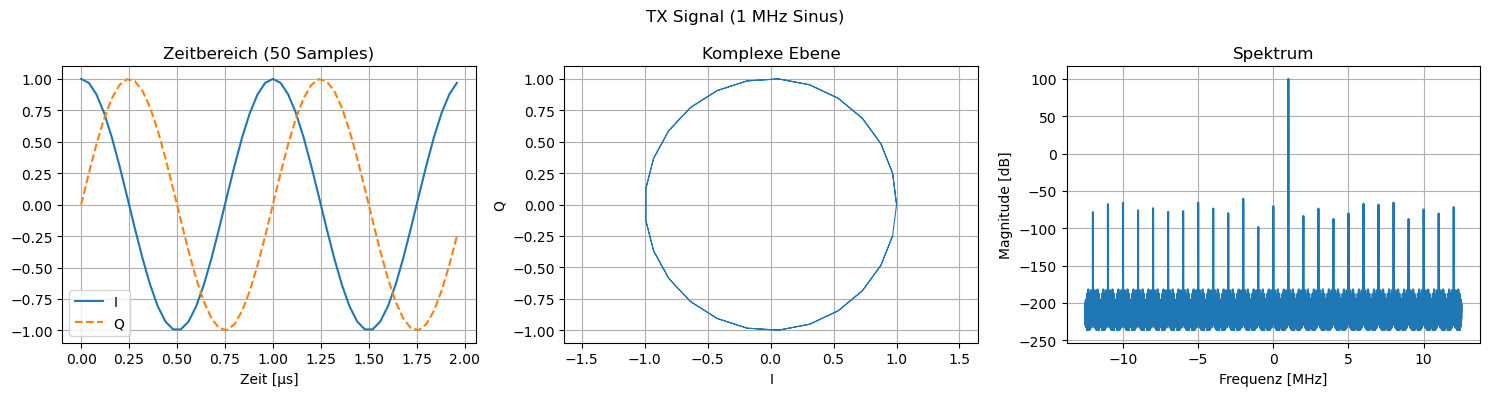

In [129]:
def plot_signal(signal, fs, title="Signal", n_time=50):
    signal = np.asarray(signal)
    n = len(signal)
    t = np.arange(n) / fs

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(title)

    m = min(n_time, n)
    axes[0].plot(t[:m]*1e6, signal[:m].real, label="I")
    axes[0].plot(t[:m]*1e6, signal[:m].imag, label="Q", linestyle="--")
    axes[0].set_xlabel("Zeit [µs]"); axes[0].legend(); axes[0].grid(True)
    axes[0].set_title(f"Zeitbereich ({m} Samples)")

    axes[1].plot(signal[:m].real, signal[:m].imag, linewidth=0.8)
    axes[1].set_xlabel("I"); axes[1].set_ylabel("Q"); axes[1].axis("equal"); axes[1].grid(True)
    axes[1].set_title("Komplexe Ebene")

    sp = np.fft.fftshift(np.fft.fft(signal))
    fr = np.fft.fftshift(np.fft.fftfreq(n, d=1/fs))
    axes[2].plot(fr/1e6, 20*np.log10(np.abs(sp) + 1e-12))
    axes[2].set_xlabel("Frequenz [MHz]"); axes[2].set_ylabel("Magnitude [dB]")
    axes[2].set_title("Spektrum"); axes[2].grid(True)

    plt.tight_layout(); plt.show()

plot_signal(tx_signal, fs, title="TX Signal (1 MHz Sinus)")

## 5. Senden & Empfangen

Signal geht an den Server, durchläuft TX-USRP → Kabel → 10 dB Attenuator → RX-USRP, und kommt zurück.
`verbose=True` zeigt Live-Status (Upload, Queue, Running, Done).

In [130]:
rx_signal = USRPClient.send(tx_signal, verbose=True)

print(f"\nTX: {len(tx_signal):,} Samples  =  {len(tx_signal)/fs*1000:.2f} ms")
print(f"RX: {len(rx_signal):,} Samples  =  {len(rx_signal)/fs*1000:.2f} ms")

tx_power_db = 10 * np.log10(np.mean(np.abs(tx_signal)**2))
rx_power_db = 10 * np.log10(np.mean(np.abs(rx_signal)**2) + 1e-20)
rx_max = np.max(np.abs(rx_signal))
print(f"TX Power:     {tx_power_db:.1f} dB")
print(f"RX Power:     {rx_power_db:.1f} dB  (über die ganze Aufnahme inkl. Guards)")
print(f"RX max |z|:   {rx_max:.3f}   (sollte < 0.9 sein, sonst Clipping)")

[upload] Sent 800,000 bytes (100,000 samples)
[info] USRP | Carrier: 2400 MHz | BW: 25 MHz | Rate: 25 MSps | SNR: 20.0 dB
[queued] Task 9c1df608... — next in line
[done] Processing complete                
[download] Receiving result...
[download] 40,800,000 bytes received — 5,100,000 samples

TX: 100,000 Samples  =  4.00 ms
RX: 5,100,000 Samples  =  204.00 ms
TX Power:     0.0 dB
RX Power:     -18.0 dB  (über die ganze Aufnahme inkl. Guards)
RX max |z|:   1.149   (sollte < 0.9 sein, sonst Clipping)


## 6. Struktur des RX-Signals

Was du zurückbekommst ist **Guard + Signal + Guard**:

```
  [───── Begin Guard ─────][── Signal ──][───── End Guard ─────]
         ~100 ms Rauschen   ~4 ms Sinus         ~100 ms Rauschen
```

Die Guards sind standardmässig ~100 ms (uniform-random zwischen `begin_guard_min/max` und `end_guard_min/max`, siehe Server-Info).

Power-Verteilung über die Zeit zeigt, wo das Signal tatsächlich liegt:

In [121]:
n_blocks = 10
n = len(rx_signal)
block_len = n // n_blocks

print(f"  {'Zeit':>10}   {'Power':>8}   Verteilung")
print("  " + "─" * 58)
for i in range(n_blocks):
    chunk = rx_signal[i*block_len:(i+1)*block_len]
    p = 10 * np.log10(np.mean(np.abs(chunk)**2) + 1e-20)
    t_ms = i * block_len / fs * 1000
    bar = "█" * max(0, int((p + 80) / 3))
    print(f"  t={t_ms:6.1f} ms   {p:7.1f} dB  {bar}")

        Zeit      Power   Verteilung
  ──────────────────────────────────────────────────────────
  t=   0.0 ms     -68.3 dB  ███
  t=  20.4 ms     -68.3 dB  ███
  t=  40.8 ms     -68.3 dB  ███
  t=  61.2 ms     -68.2 dB  ███
  t=  81.6 ms     -11.0 dB  ███████████████████████
  t= 102.0 ms     -11.0 dB  ██████████████████████
  t= 122.4 ms     -68.3 dB  ███
  t= 142.8 ms     -68.3 dB  ███
  t= 163.2 ms     -68.3 dB  ███
  t= 183.6 ms     -68.3 dB  ███


## 7. ⚠️  Naiv plotten zeigt nur Rauschen

`plot_signal(rx_signal, fs)` plottet die ersten 500 Samples (= 20 µs). Die liegen **komplett im Begin-Guard** → nur Rauschen, obwohl das Signal perfekt empfangen wurde.

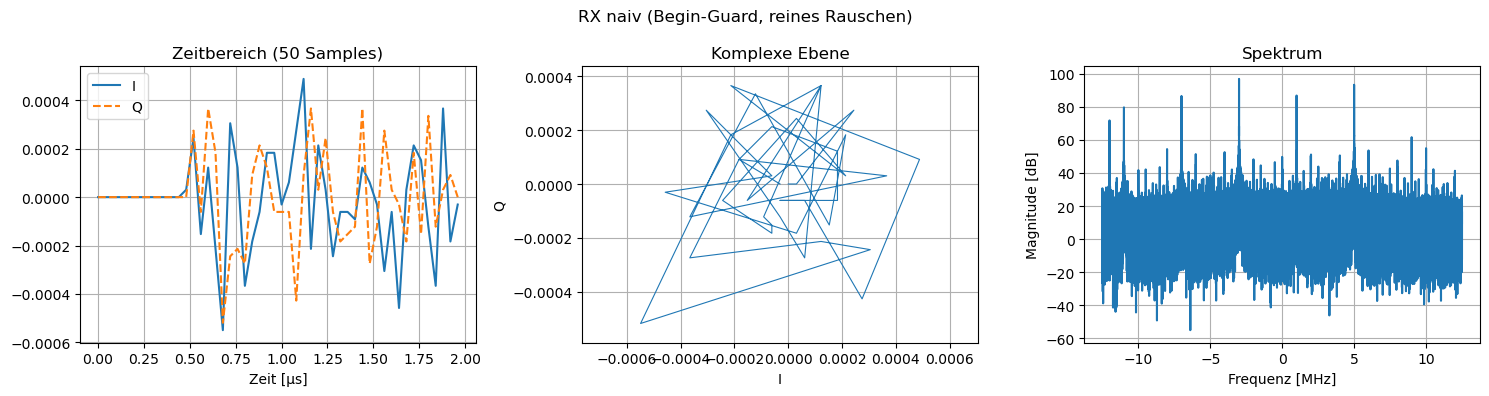

In [122]:
plot_signal(rx_signal, fs, title="RX naiv (Begin-Guard, reines Rauschen)")

## 8. Signal mit festem Offset herausschneiden

Da `begin_guard_min == begin_guard_max` (beide 0.1 s) kennst du den Start exakt.
Dein Signal beginnt bei Sample `int(begin_guard * fs)`:

Guard-Offset: 2,500,000 Samples (100.0 ms)
rx_core Länge: 100,000 Samples (sollte = 100,000)
rx_core Power: -0.9 dB


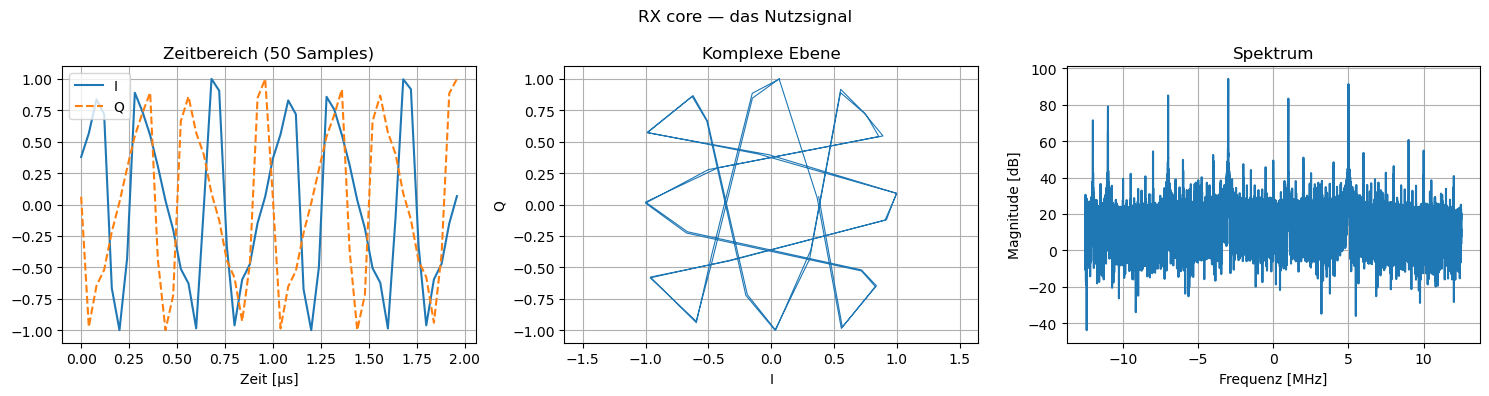

In [123]:
begin_guard_s = info.get('begin_guard_min_sec', 0.1)
guard_samples = int(begin_guard_s * fs)

rx_core = rx_signal[guard_samples : guard_samples + len(tx_signal)]

print(f"Guard-Offset: {guard_samples:,} Samples ({begin_guard_s*1000:.1f} ms)")
print(f"rx_core Länge: {len(rx_core):,} Samples (sollte = {len(tx_signal):,})")
print(f"rx_core Power: {10*np.log10(np.mean(np.abs(rx_core)**2)):.1f} dB")

plot_signal(rx_core, fs, title="RX core — das Nutzsignal")

## 9. Frequenz-Check: passt das Spektrum?

Die beiden USRPs laufen auf **unabhängigen internen Clocks** (kein gemeinsames 10 MHz-Reference). Daraus ergibt sich ein kleiner Frequenz-Offset zwischen TX- und RX-LO, meist wenige hundert Hz. Der FFT-Peak sollte aber sehr nah bei 1 MHz liegen.

In [106]:
sp = np.fft.fftshift(np.fft.fft(rx_core))
fr = np.fft.fftshift(np.fft.fftfreq(len(rx_core), d=1/fs))
peak_idx = int(np.argmax(np.abs(sp)))
f_observed = fr[peak_idx]

print(f"Erwartet:  {tone_freq/1e6:.4f} MHz")
print(f"Gemessen:  {f_observed/1e6:.4f} MHz")
print(f"Offset:    {(f_observed - tone_freq):.1f} Hz")

Erwartet:  1.0000 MHz
Gemessen:  -2.9995 MHz
Offset:    -3999500.0 Hz


## 10. Was du sehen solltest

| Plot | Erwartung |
|---|---|
| **Zeitbereich** | Saubere I/Q-Sinuswellen, I und Q um 90° verschoben |
| **Komplexe Ebene** | Glatter Kreis (Amplitude konstant, Phase dreht sanft weiter) |
| **Spektrum** | Scharfer Peak bei **+1 MHz**, tiefer Rauschboden |

**Problem-Diagnose:**

- **Star / Polygon statt Kreis** → falscher Slice-Offset, `guard_samples` passt nicht
- **Mehrere starke Peaks im Spektrum** → Clipping (`rx max |z| > 1`) oder Interferer
- **Peak weit weg von 1 MHz** → Clock-Drift zwischen den USRPs oder falsche Sample-Rate
- **Alles Rauschen trotz rx_core** → Kabel/USRP-Pfad prüfen, Server-Logs checken

---

## Damit hast du:

| Variable | Inhalt |
|---|---|
| `tx_signal` | Was du gesendet hast |
| `rx_signal` | Komplette Aufnahme (~204 ms, inkl. Guards) |
| `rx_core`   | Nur das Nutzsignal, zeit-akkurat ausgerichtet |

Damit kannst du SNR messen, Kanal-Response schätzen, Modulationen dekodieren usw.

### Tipp für eigene Messungen

Reine Sinuswellen sind schlecht für automatische Zeit-Alignment (periodische Autokorrelation). 
Für robuste Auto-Alignment benutze **Signale mit scharfer Autokorrelation** — z.B. Zadoff-Chu, m-Sequenzen, oder einen Chirp am Anfang des Bursts als Sync-Header.

In [107]:
# Was ist die tatsächliche Peak-Frequenz im RX?
begin_guard_s = info.get('begin_guard_min_sec', 0.1)
guard_samples = int(begin_guard_s * fs)
rx_core = rx_signal[guard_samples : guard_samples + len(tx_signal)]

sp = np.fft.fftshift(np.fft.fft(rx_core))
fr = np.fft.fftshift(np.fft.fftfreq(len(rx_core), d=1/fs))
peak_idx = int(np.argmax(np.abs(sp)))
f_observed = fr[peak_idx]

print(f"TX-Frequenz (was wir senden wollten): {tone_freq/1e6:.4f} MHz")
print(f"RX-Peak-Frequenz (was wir sehen):     {f_observed/1e6:.4f} MHz")
print(f"Ratio: {f_observed/tone_freq:.3f}x")

TX-Frequenz (was wir senden wollten): 1.0000 MHz
RX-Peak-Frequenz (was wir sehen):     -2.9995 MHz
Ratio: -2.999x
